# Exploratory Data Analysis: German Credit Risk Dataset

**Dataset:** UCI German Credit Data (1000 applicants, 20 features, ~30% default rate)  
**Goal:** Understand feature distributions, identify key default predictors, and validate data quality before modelling.

Plots are saved to `../assets/screenshots/` for inclusion in the README.

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from src.data_loader import load_german_credit, run_data_pipeline, run_vintage_analysis

SCREENSHOTS = Path('../assets/screenshots')
SCREENSHOTS.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'good': '#4CAF50', 'bad': '#F44336'}

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [4]:
df = load_german_credit()
print(f'Shape: {df.shape}')
print(f'Default rate: {df["default_flag"].mean():.1%}')
df.head(3)

Shape: (1000, 21)
Default rate: 30.0%


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,default_flag
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0


In [5]:
print('Dtypes:')
print(df.dtypes.to_string())
print('\nNumeric summary:')
df.describe().round(2)

Dtypes:
checking_status           object
duration                   int64
credit_history            object
purpose                   object
credit_amount              int64
savings_status            object
employment                object
installment_commitment     int64
personal_status           object
other_parties             object
residence_since            int64
property_magnitude        object
age                        int64
other_payment_plans       object
housing                   object
existing_credits           int64
job                       object
num_dependents             int64
own_telephone             object
foreign_worker            object
default_flag               int32

Numeric summary:


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,default_flag
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16,0.30
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36,0.46
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00,0.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00,0.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00,0.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00,1.00


## 2. Target Distribution

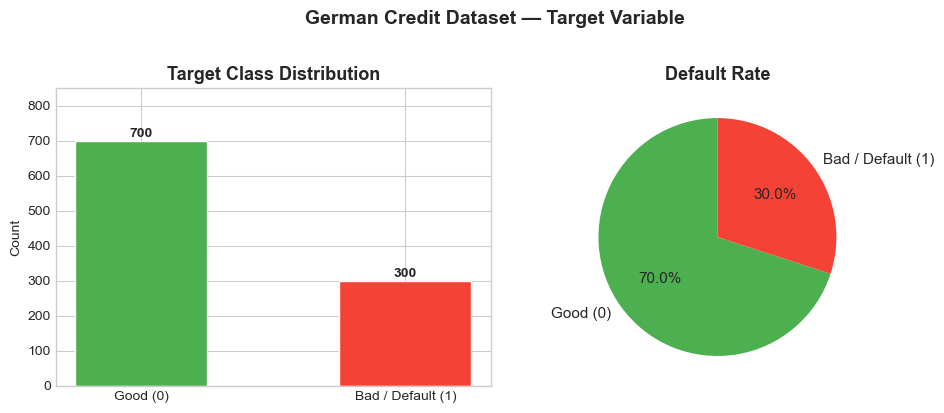

Saved: eda_target_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['default_flag'].value_counts().sort_index()
labels = ['Good (0)', 'Bad / Default (1)']
colors = ['#4CAF50', '#F44336']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 850)

# Pie chart
axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Default Rate', fontsize=13, fontweight='bold')

plt.suptitle('German Credit Dataset — Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_target_distribution.png')

## 3. Missing Value Analysis

Total missing values: 0

Missing per column:
None — dataset is complete.


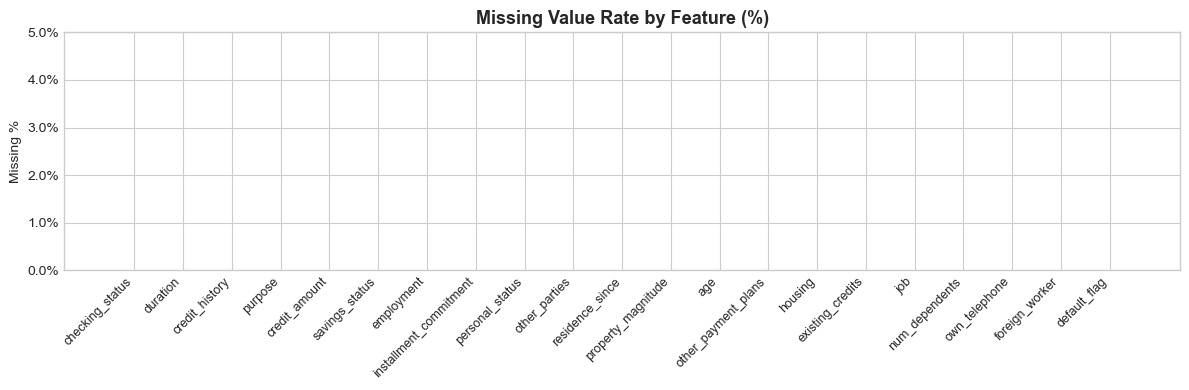

In [9]:
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
print('\nMissing per column:')
print(missing[missing > 0].to_string() if missing.sum() > 0 else 'None — dataset is complete.')

fig, ax = plt.subplots(figsize=(12, 4))
missing_pct = df.isnull().mean() * 100
ax.bar(missing_pct.index, missing_pct.values, color='#2196F3', alpha=0.7)
ax.set_title('Missing Value Rate by Feature (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_ylim(0, 5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bivariate Analysis — Categorical Features vs Default Rate

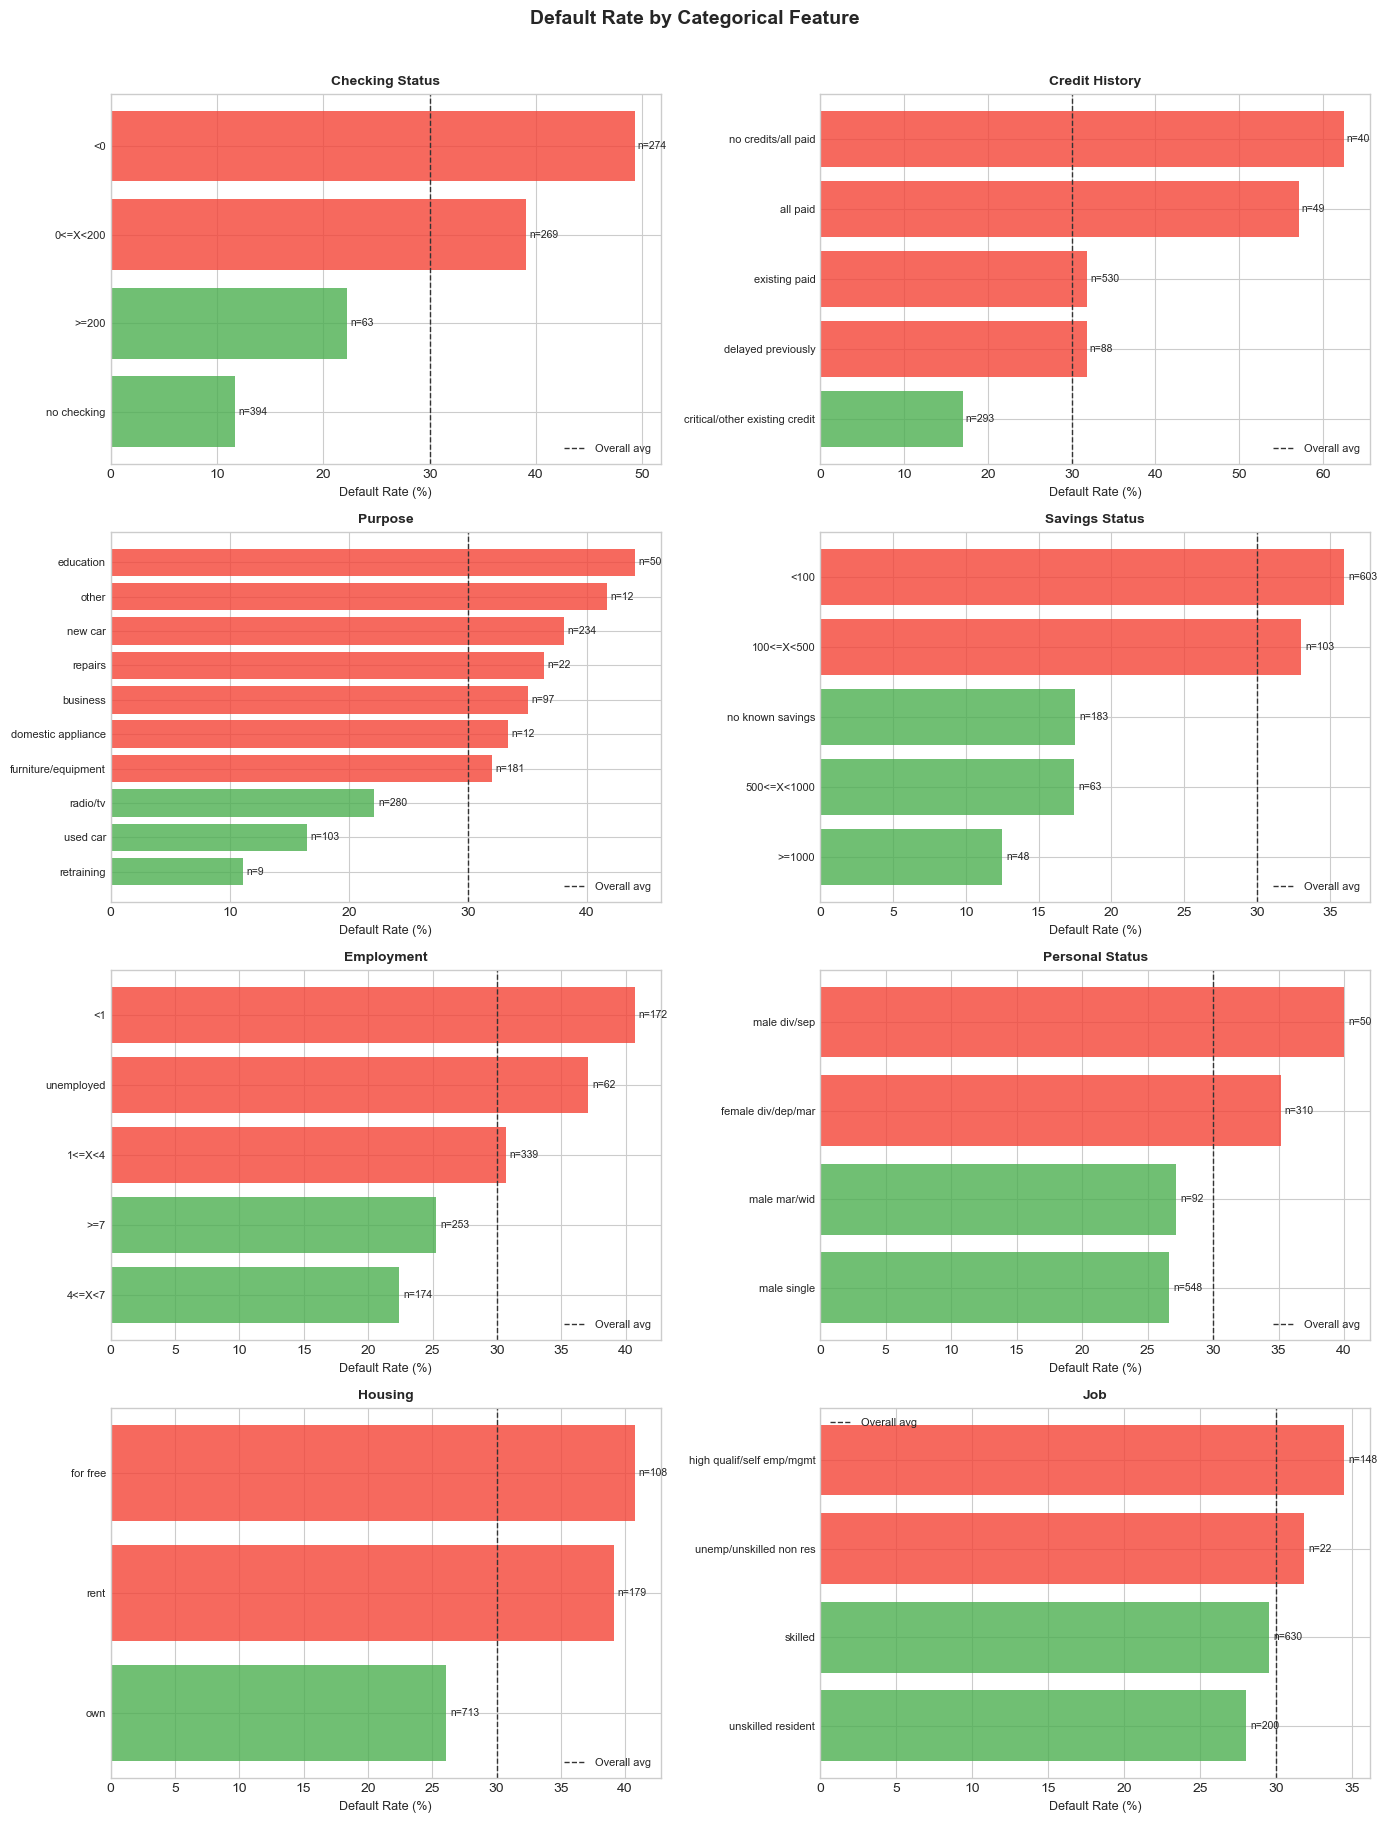

Saved: eda_bivariate.png


In [11]:
cat_cols = [
    'checking_status', 'credit_history', 'purpose', 'savings_status',
    'employment', 'personal_status', 'housing', 'job'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    dr = df.groupby(col)['default_flag'].agg(['mean', 'count']).reset_index()
    dr = dr.sort_values('mean', ascending=True)
    
    bars = axes[i].barh(
        dr[col], dr['mean'] * 100,
        color=[f'#F44336' if v > df['default_flag'].mean() else '#4CAF50' for v in dr['mean']],
        alpha=0.8
    )
    axes[i].axvline(df['default_flag'].mean() * 100, color='#333', linestyle='--', lw=1, label='Overall avg')
    
    for bar, (_, row) in zip(bars, dr.iterrows()):
        axes[i].text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}", va='center', fontsize=7.5
        )
    
    axes[i].set_xlabel('Default Rate (%)', fontsize=9)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Default Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_bivariate.png')

## 5. Numeric Feature Distributions by Target

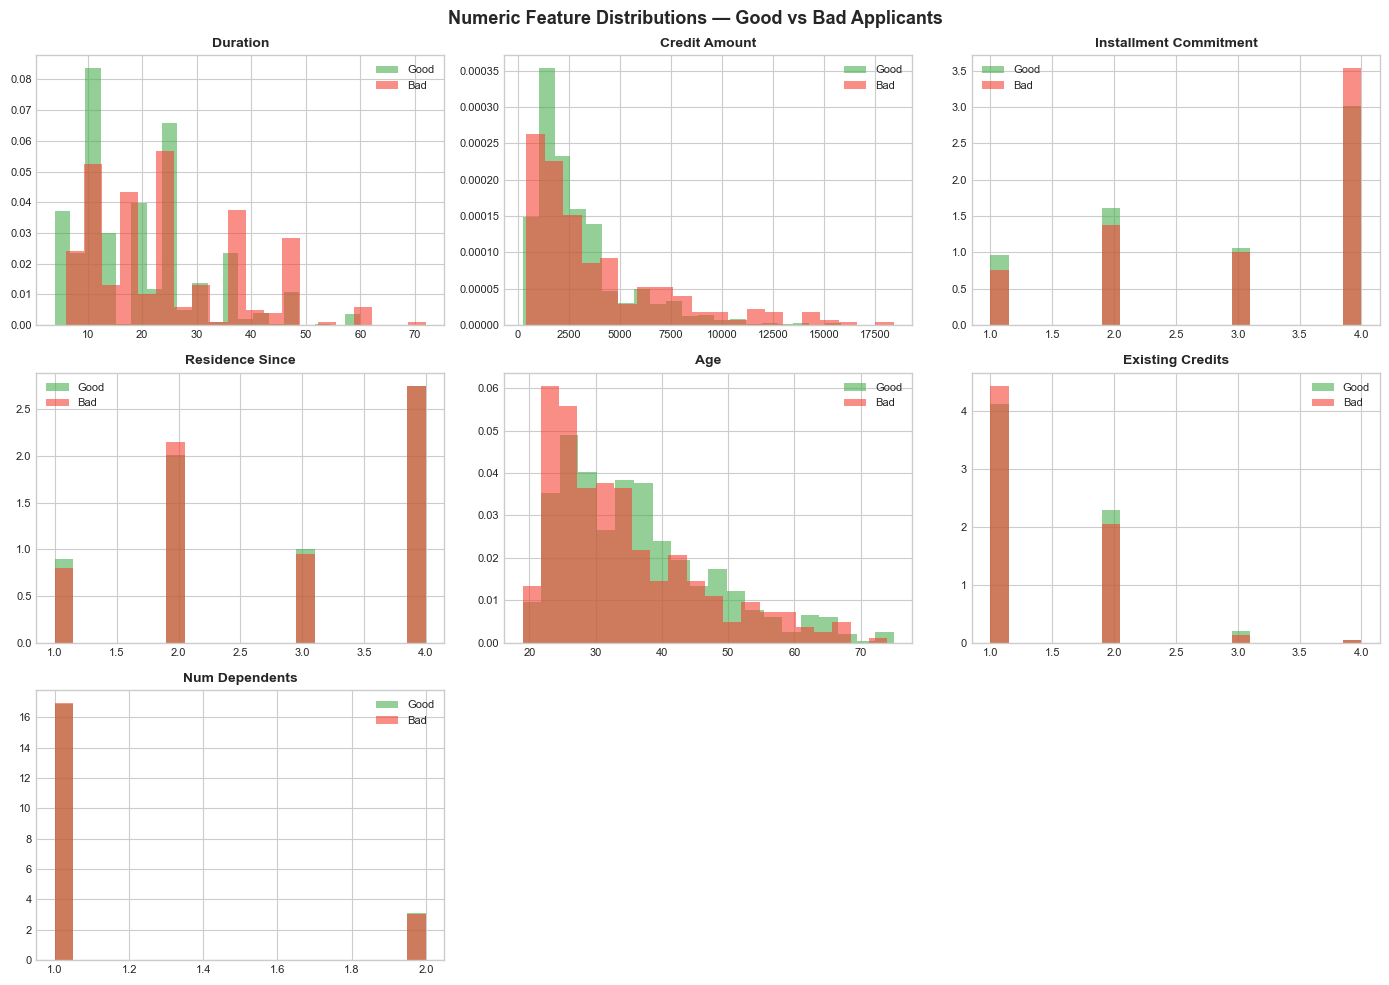

In [13]:
num_cols = ['duration', 'credit_amount', 'installment_commitment',
            'residence_since', 'age', 'existing_credits', 'num_dependents']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

good = df[df['default_flag'] == 0]
bad  = df[df['default_flag'] == 1]

for i, col in enumerate(num_cols):
    axes[i].hist(good[col], bins=20, alpha=0.6, color='#4CAF50', density=True, label='Good')
    axes[i].hist(bad[col],  bins=20, alpha=0.6, color='#F44336', density=True, label='Bad')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions — Good vs Bad Applicants',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Matrix (Numeric Features)

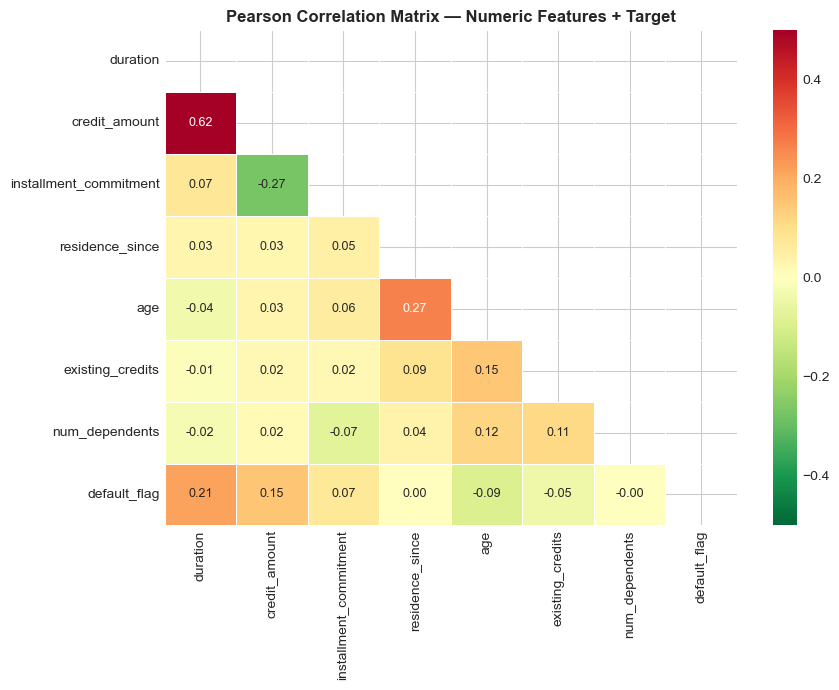

Saved: eda_correlation_matrix.png

Correlation with default_flag (sorted):
duration                  0.214927
credit_amount             0.154739
age                      -0.091127
installment_commitment    0.072404
existing_credits         -0.045732
num_dependents           -0.003015
residence_since           0.002967


In [15]:
corr_df = df[num_cols + ['default_flag']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix — Numeric Features + Target',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation_matrix.png')
print('\nCorrelation with default_flag (sorted):')
print(corr_df['default_flag'].sort_values(key=abs, ascending=False).drop('default_flag').to_string())

## 7. Vintage Analysis — Default Rate by Credit Duration Bucket

Runs the `sql/vintage_analysis.sql` window-function query against the SQLite feature store,
demonstrating SQL proficiency with `LAG()` and `PARTITION BY`.

In [17]:
# Ensure database is populated
run_data_pipeline()
vintage = run_vintage_analysis()
print(vintage.to_string(index=False))

duration_bucket  total_applications  total_defaults  default_rate_pct  prev_bucket_default_rate  default_rate_change_pct  avg_duration_months  pct_of_portfolio
       01_0-12m                 359              76             21.17                       NaN                      NaN                  9.9              35.9
      02_13-24m                 411             122             29.68                     21.17                     8.51                 20.4              41.1
      03_25-36m                 143              57             39.86                     29.68                    10.18                 33.2              14.3
      04_37-48m                  71              37             52.11                     39.86                    12.25                 46.1               7.1
        05_49m+                  16               8             50.00                     52.11                    -2.11                 60.0               1.6


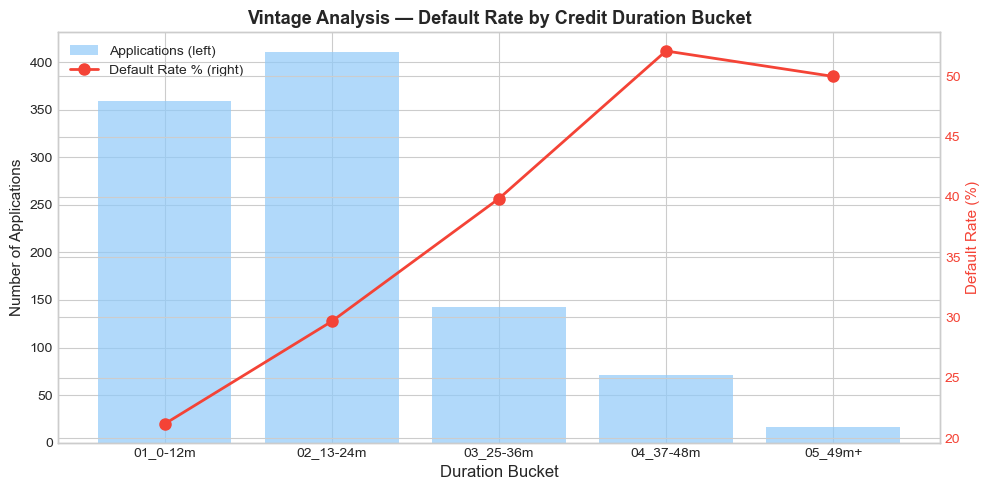

Saved: eda_vintage_analysis.png


In [18]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(vintage))
ax1.bar(x, vintage['total_applications'], color='#90CAF9', alpha=0.7, label='Applications (left)')
ax2.plot(x, vintage['default_rate_pct'], 'o-', color='#F44336', linewidth=2,
         markersize=8, label='Default Rate % (right)')

ax1.set_xticks(list(x))
ax1.set_xticklabels(vintage['duration_bucket'], fontsize=10)
ax1.set_xlabel('Duration Bucket', fontsize=12)
ax1.set_ylabel('Number of Applications', fontsize=11)
ax2.set_ylabel('Default Rate (%)', fontsize=11, color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.set_title('Vintage Analysis — Default Rate by Credit Duration Bucket',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'eda_vintage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_vintage_analysis.png')

## 8. Key EDA Findings

| Finding | Implication for Modelling |
|---------|---------------------------|
| `checking_status = 'no checking'` has ~45% default rate vs 13% for '>=200' | Strongest single predictor — expect high IV |
| Default rate rises monotonically with loan duration | Duration is an excellent ordinal predictor |
| Applicants with `credit_history = 'critical'` have the highest default rate | Capturing past delinquency is critical |
| Age and credit_amount are weakly correlated (r ≈ 0.03) | No multicollinearity concern |
| Duration and credit_amount are positively correlated (r ≈ 0.62) | May create redundancy — IV selection will handle |
| No missing values | No imputation step needed |

**Proceed to `src/feature_engineering.py` for WoE encoding and IV-based feature selection.**